# Градиентный бустинг

<h3>План занятия</h3>

* **Две философии ансамблей** — где мы и куда движемся (дерево → лес → бустинг)
* **Идея бустинга** — последовательное исправление ошибок
* **Почему «градиентный»** — связь с градиентным спуском (SGD)
* **Темп обучения и переобучение**
* **Классификация и бустинг над линейными моделями** (в т.ч. логистической регрессией)
* **От `GradientBoosting` к XGBoost / LightGBM / CatBoost**
* **Практическая настройка** — с чего начинать и на что смотреть
* **Когда выбирать бустинг и как его интерпретировать**

> Это занятие опирается на ноутбуки `dt_demo` (деревья), `bias_variance_demo`
> (разложение ошибки) и `bagging_rf` (бэггинг и случайный лес). Если разложение
> ошибки на **смещение** и **разброс** не свежо в памяти — стоит вернуться к нему,
> потому что бустинг проще всего понять именно через него.


In [ ]:
import warnings
warnings.simplefilter("ignore")

import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_gaussian_quantiles, make_friedman1
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              GradientBoostingClassifier, HistGradientBoostingRegressor)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, accuracy_score

from ipywidgets import interact, IntSlider, FloatSlider

plt.rcParams['figure.figsize'] = (9, 5)
np.random.seed(42)

Несколько игрушечных наборов данных, на которых будем всё показывать.

In [ ]:
def make_reg_1d(n=80, noise=0.25, seed=0):
    """1D regression target with a couple of bends, plus Gaussian noise."""
    rng = np.random.RandomState(seed)
    x = np.sort(rng.uniform(-5, 5, n))
    y = np.sin(x) + 0.3 * x + rng.randn(n) * noise
    return x.reshape(-1, 1), y


def make_linear_1d(n=60, noise=1.0, seed=0):
    """1D approximately linear data: y = 2x + 1 + noise."""
    rng = np.random.RandomState(seed)
    x = np.sort(rng.uniform(-3, 3, n))
    y = 2.0 * x + 1.0 + rng.randn(n) * noise
    return x.reshape(-1, 1), y


def make_circle_data(n=400, seed=0):
    """Inner blob (class 0) wrapped by an outer ring (class 1).

    A single straight line cannot separate these two classes.
    """
    X, y = make_gaussian_quantiles(n_samples=n, n_features=2,
                                   n_classes=2, random_state=seed)
    return X, y

In [ ]:
# 1D regression data — for the step-by-step and learning-rate demos
x1d, y1d = make_reg_1d(n=80, noise=0.25, seed=0)
grid1d = np.linspace(x1d.min(), x1d.max(), 400).reshape(-1, 1)

# tabular regression with interactions + noise — for boosting-vs-bagging, tuning
X_fr, y_fr = make_friedman1(n_samples=600, noise=2.0, random_state=0)
Xtr, Xte, ytr, yte = train_test_split(X_fr, y_fr, test_size=0.3, random_state=0)

# 2D "circle in a circle" classification data
X_circ, y_circ = make_circle_data(n=400, seed=0)

In [ ]:
#@title Вспомогательная функция отрисовки границы (можно не читать) { display-mode: "form" }
def plot_decision_boundary(model, X, y, ax, title=""):
    """Draw filled decision regions of a fitted classifier over a 2D grid."""
    h = 0.05
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.7)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=1.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu_r', edgecolor='k', s=25)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

## 1. Две философии построения ансамбля

Одна модель-дерево обычно имеет **низкое смещение, но высокий разброс**: она легко
подстраивается под данные, но сильно меняется от выборки к выборке. Есть два разных
способа собрать из деревьев надёжный ансамбль.

| | Случайный лес (бэггинг) | Бустинг |
|---|---|---|
| как строятся модели | **параллельно**, независимо | **последовательно**, одна за другой |
| что делает каждая | учится на своей подвыборке | исправляет ошибки предыдущих |
| какие базовые модели | **сильные** (глубокие деревья) | **слабые** (неглубокие деревья) |
| с чем борется | с **разбросом** (variance) | со **смещением** (bias) |
| риск | почти не переобучается от числа деревьев | **переобучается**, если деревьев слишком много |

Случайный лес говорит: «построим много хороших моделей и усредним их разброс».
Бустинг говорит: «возьмём слабую модель и будем шаг за шагом исправлять её ошибки,
пока смещение не станет маленьким». Сегодня — про второй путь.


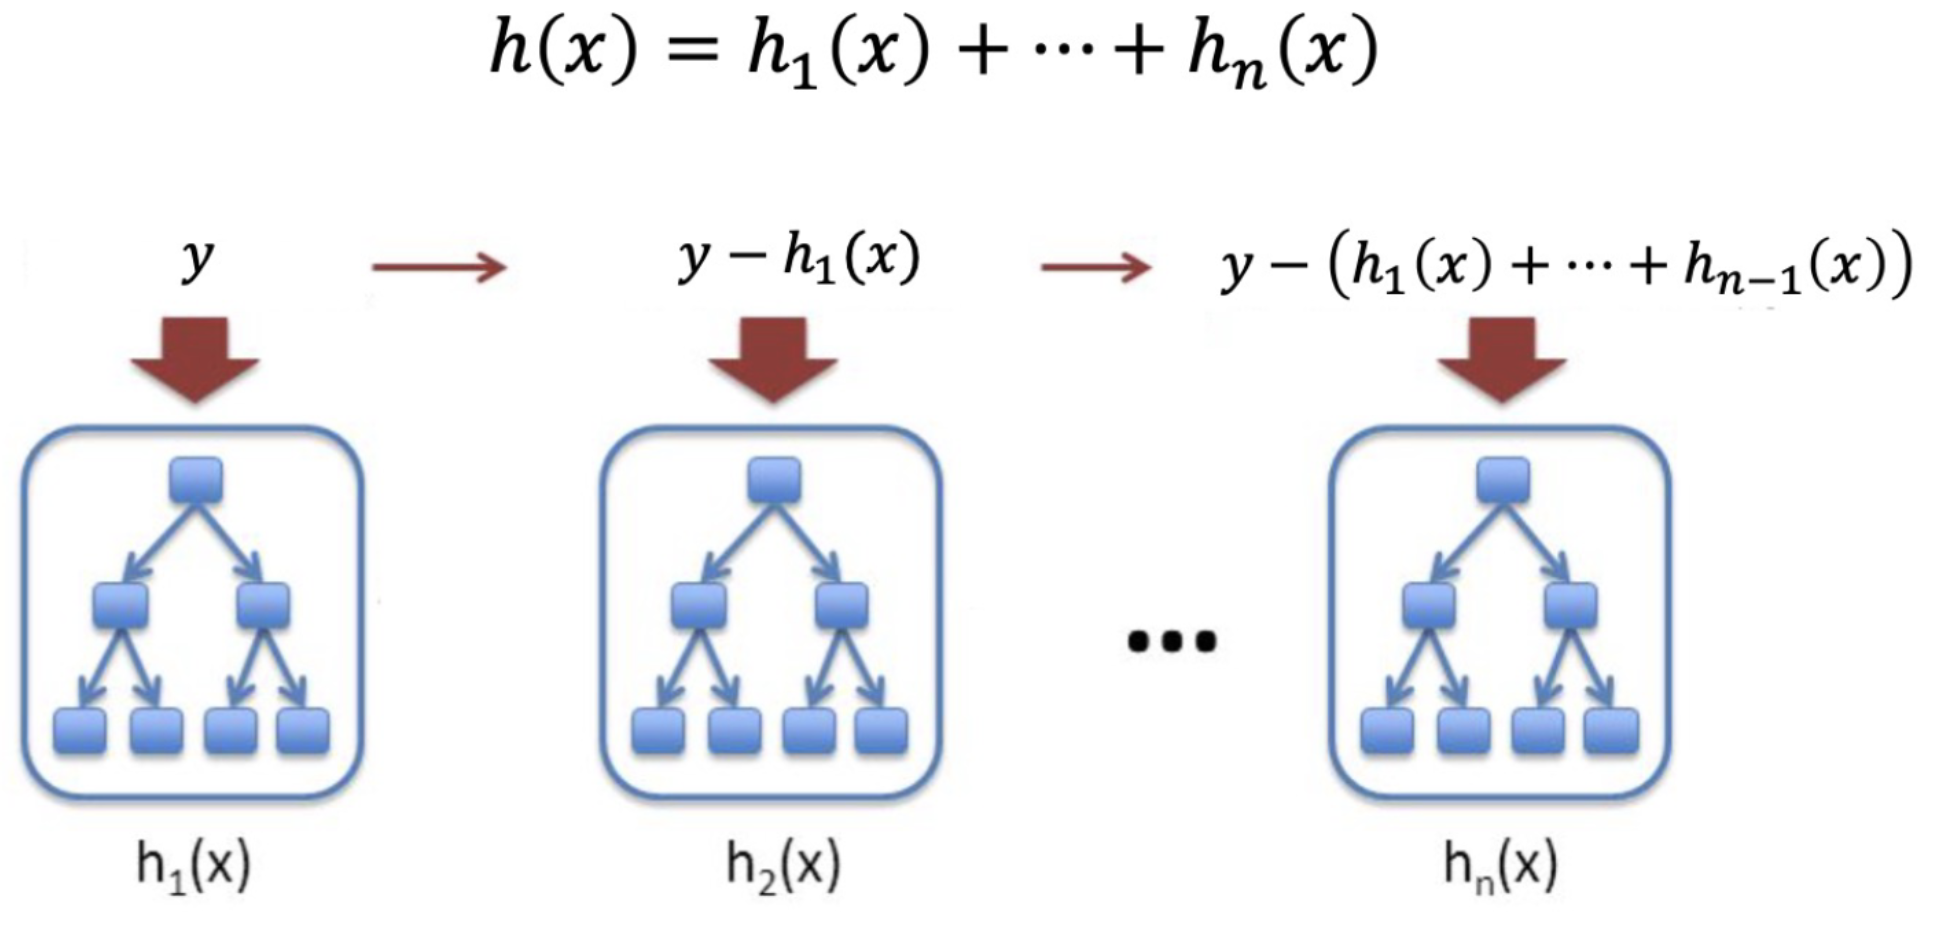

## 2. Идея бустинга: учимся на остатках

Возьмём задачу регрессии и квадратичную ошибку. Пусть после нескольких шагов наш
ансамбль выдаёт предсказание $F(x)$. Ошибка на объекте — это **остаток**:

$$r_i = y_i - F(x_i)$$

Идея бустинга предельно простая:

> обучим **новое** дерево предсказывать не сам ответ $y$, а **остаток** $r$ —
> то, чего текущему ансамблю не хватает. Затем добавим это дерево к ансамблю.

$$F_{\text{new}}(x) = F(x) + h(x), \qquad h \approx (y - F)$$

Каждое следующее дерево «доедает» ошибку предыдущих. Покрутите число деревьев $M$:
слева — как ансамбль приближает данные, справа — как тают остатки.


In [ ]:
#@title Интерактив: бустинг собирает ответ по шагам { display-mode: "form" }
def boosting_steps_demo(M=1, max_depth=2):
    """Show the ensemble prediction and the shrinking residuals after M steps."""
    model = GradientBoostingRegressor(n_estimators=120, learning_rate=0.3,
                                      max_depth=int(max_depth))
    model.fit(x1d, y1d)
    m = int(M) - 1
    pred_grid = list(model.staged_predict(grid1d))[m]
    resid = y1d - list(model.staged_predict(x1d))[m]

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    ax[0].scatter(x1d, y1d, color='grey', edgecolor='black', s=30, label='данные')
    ax[0].plot(grid1d, pred_grid, color='crimson', lw=2.5, label=f'ансамбль F (M={int(M)})')
    ax[0].set_title('Предсказание ансамбля')
    ax[0].legend(loc='upper left')
    ax[1].scatter(x1d, resid, color='steelblue', edgecolor='black', s=30)
    ax[1].axhline(0, color='black', lw=1)
    ax[1].set_title(f'Остатки y − F     (MSE = {np.mean(resid**2):.3f})')
    plt.ylim(-1.5, 1.5)
    plt.show()

interact(boosting_steps_demo,
         M=IntSlider(value=1, min=1, max=120, step=1, description='Деревьев M'),
         max_depth=IntSlider(value=2, min=1, max=6, step=1, description='Глубина'));

Обратите внимание: при `Глубина = 1` каждое дерево — это один «порог» (пень,
*stump*), и ансамбль складывает ответ из множества маленьких ступенек. Чем больше
деревьев, тем мельче остатки — пока модель не начнёт подстраиваться под шум
(об этом дальше).


## 3. Почему бустинг «градиентный»: связь с градиентным спуском

«Учиться на остатках» — это частный случай. Чтобы понять слово **градиентный**,
вспомним обычный градиентный спуск (тот самый, что в SGD).

**Обычный градиентный спуск (по параметрам).** Мы минимизируем функцию потерь
$L(\theta)$ и двигаем *параметры* против градиента:

$$\theta_{t+1} = \theta_t - \eta\, \nabla_\theta L(\theta_t)$$

**Бустинг — это градиентный спуск, но по функции, а не по параметрам.** Мы хотим
минимизировать суммарную ошибку по самой функции предсказаний $F$:

$$L(F) = \sum_{i=1}^N \mathcal{L}\big(y_i, F(x_i)\big)$$

Посмотрим на «параметры» как на сами значения $F(x_1), \dots, F(x_N)$. Тогда
производная ошибки по предсказанию на объекте $i$:

$$g_i = \frac{\partial \mathcal{L}(y_i, F(x_i))}{\partial F(x_i)}$$

Идеальный шаг спуска — сдвинуть каждое предсказание против градиента:
$F(x_i) \leftarrow F(x_i) - \eta\, g_i$. Но так мы поправим только обучающие точки
и не получим функцию, которая обобщается на новые $x$. Поэтому мы **обучаем дерево
$h_m$ приближать антиградиент** $(-g_1, \dots, -g_N)$ — это обычная задача регрессии —
и делаем шаг:

$$F_m(x) = F_{m-1}(x) + \eta\, h_m(x)$$

Здесь:
- $-g_i$ называют **псевдоостатком** — это «обобщённый остаток» для произвольной потери;
- $h_m$ — дерево, сглаженная и обобщаемая версия антиградиента;
- $\eta$ — **темп обучения** (learning rate), тот же размер шага, что и в SGD.

**Ключевая проверка.** Для квадратичной потери $\mathcal{L} = \tfrac12 (y - F)^2$:

$$-g_i = -\frac{\partial}{\partial F}\Big[\tfrac12 (y_i - F)^2\Big] = (y_i - F(x_i)) = r_i$$

То есть «учиться на остатках» из раздела 2 — это и есть градиентный спуск для MSE.
Для других потерь антиградиент выглядит иначе (для логистической, например,
$-g_i = y_i - p_i$), но схема та же.

**Начальная точка.** $F_0$ — это лучшая константа, минимизирующая суммарную потерю
(для MSE — среднее $\bar y$). Это ровно то «лучшее константное предсказание», через
которое мы определяли impurity в ноутбуке про деревья.


In [ ]:
#@title Интерактив: бустинг линейных моделей — это спуск к решению OLS { display-mode: "form" }
xl, yl = make_linear_1d(n=60, noise=1.0, seed=0)
ols = LinearRegression().fit(xl, yl)          # the solution we converge to
grid_l = np.linspace(xl.min(), xl.max(), 400).reshape(-1, 1)

def linear_boost_demo(M=1, learning_rate=0.1):
    """Boost linear regressors on the residuals (negative MSE gradient).

    The sum of linear models stays linear and converges to the ordinary
    least-squares line -- gradient descent in function space, step by step.
    """
    F = np.full_like(yl, yl.mean(), dtype=float)
    coef, intercept = np.zeros(1), float(yl.mean())
    for _ in range(int(M)):
        r = yl - F                            # pseudo-residual = negative gradient
        h = LinearRegression().fit(xl, r)
        F = F + learning_rate * h.predict(xl)
        coef = coef + learning_rate * h.coef_
        intercept = intercept + learning_rate * h.intercept_
    pred_grid = grid_l.ravel() * coef[0] + intercept

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(xl, yl, color='grey', edgecolor='black', s=25)
    ax.plot(grid_l, ols.predict(grid_l), 'k--', lw=2, label='OLS (цель)')
    ax.plot(grid_l, pred_grid, color='crimson', lw=2.5, label=f'бустинг, M={int(M)}')
    ax.set_title(f'η = {learning_rate}, M = {int(M)}:  наклон {coef[0]:.2f} → OLS {ols.coef_[0]:.2f}')
    ax.legend()
    plt.show()

interact(linear_boost_demo,
         M=IntSlider(value=1, min=1, max=100, step=1, description='Шагов M'),
         learning_rate=FloatSlider(value=0.1, min=0.01, max=1.0, step=0.01, description='η'));

Здесь видно сразу две вещи.

1. **Это буквально градиентный спуск.** Красная прямая стартует от среднего
   (горизонталь) и шаг за шагом поворачивается к решению OLS. Темп $\eta$ — размер
   шага: меньше $\eta$ → медленнее сходимость, больше шагов нужно.

2. **Сумма линейных моделей остаётся линейной.** Сколько ни добавляй линейных
   базовых моделей, граница/прямая не станет кривой — мы лишь точнее находим
   *ту же самую* линейную зависимость. Поэтому **гибкость бустингу даёт не сам
   бустинг, а нелинейность базовой модели** (неглубокие деревья). Это та же мысль,
   что и про бэггинг: бустинг линейной модели не добавляет ей выразительности.


## 4. Темп обучения и переобучение

Полный шаг ($\eta = 1$) часто слишком жадный: ансамбль быстро запоминает обучающую
выборку вместе с шумом. Поэтому шаг **уменьшают** (shrinkage):

$$F_m(x) = F_{m-1}(x) + \eta\, h_m(x), \qquad 0 < \eta \le 1$$

Маленький $\eta$ замедляет обучение, но даёт более гладкую и устойчивую модель.
Возникает связка **«темп $\eta$ ↔ число деревьев $M$»**: чем меньше $\eta$, тем
больше деревьев нужно — но и переобучение наступает позже.


In [ ]:
#@title Интерактив: темп обучения и число деревьев { display-mode: "form" }
Xtr_1d, Xte_1d, ytr_1d, yte_1d = train_test_split(x1d, y1d, test_size=0.35,
                                                  random_state=0)

def lr_demo(learning_rate=0.3, M=20):
    """Show under/overfitting as a function of learning rate and tree count."""
    model = GradientBoostingRegressor(n_estimators=300,
                                      learning_rate=learning_rate, max_depth=2)
    model.fit(Xtr_1d, ytr_1d)
    m = int(M) - 1
    pg = list(model.staged_predict(grid1d))[m]
    tr = mean_squared_error(ytr_1d, list(model.staged_predict(Xtr_1d))[m])
    te = mean_squared_error(yte_1d, list(model.staged_predict(Xte_1d))[m])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(Xtr_1d, ytr_1d, color='grey', edgecolor='black', s=25, label='train')
    ax.scatter(Xte_1d, yte_1d, color='orange', edgecolor='black', s=25, label='test')
    ax.plot(grid1d, pg, color='crimson', lw=2.5)
    ax.set_title(f'η = {learning_rate}, M = {int(M)}    train MSE = {tr:.3f}   test MSE = {te:.3f}')
    ax.legend(loc='upper left')
    plt.show()

interact(lr_demo,
         learning_rate=FloatSlider(value=0.3, min=0.01, max=1.0, step=0.01, description='η'),
         M=IntSlider(value=20, min=1, max=300, step=1, description='Деревьев M'));

In [ ]:
#@title Бустинг против бэггинга: ошибка от числа моделей { display-mode: "form" }
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1,
                               max_depth=3).fit(Xtr, ytr)
boost_test = [mean_squared_error(yte, p) for p in gb.staged_predict(Xte)]

grid_M = [1, 2, 5, 10, 20, 40, 70, 100, 150, 200, 300]
bag_test = []
for M in grid_M:
    rf = RandomForestRegressor(n_estimators=M, random_state=0, n_jobs=-1).fit(Xtr, ytr)
    bag_test.append(mean_squared_error(yte, rf.predict(Xte)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, 301), boost_test, color='crimson', label='бустинг (test MSE)')
ax.plot(grid_M, bag_test, color='steelblue', marker='o', label='случайный лес (test MSE)')
ax.set_xlabel('число деревьев M')
ax.set_ylabel('test MSE')
ax.set_title('Лес выходит на плато; бустинг снижает ошибку дальше, но может переобучиться')
ax.legend()
plt.show()

Это и есть разница из таблицы в начале, в терминах разложения ошибки:

- **Случайный лес** гасит *разброс*. После некоторого числа деревьев разброс почти
  исчерпан — кривать выходит на **плато**, лишние деревья не вредят.
- **Бустинг** снижает *смещение*: ошибка на train стремится к нулю. Но если деревьев
  слишком много, модель начинает воспроизводить шум — ошибка на тесте сначала падает,
  а потом **растёт**. Отсюда два главных лекарства: маленький $\eta$ и **ранняя
  остановка** (раздел 7).


## 5. Классификация и бустинг над линейными моделями

Для классификации схема та же, меняется только функция потерь. Берут логистическую
потерю; её антиградиент (псевдоостаток) получается очень наглядным:

$$-g_i = y_i - p_i, \qquad p_i = \sigma\big(F(x_i)\big) = \frac{1}{1 + e^{-F(x_i)}}$$

то есть «насколько вероятность, которую мы предсказали, расходится с истинной меткой».

Здесь важно повторить вывод из раздела 3 уже на классификации. Если базовая модель —
**линейная** (логистическая регрессия), то итоговый логит $F = \sum_m \eta\, h_m$ —
это сумма линейных функций, а значит **снова линейная функция**. Граница останется
прямой, сколько шагов ни делай. Проверим на «круге в круге»:


In [ ]:
#@title Интерактив: бустинг логистической регрессии остаётся прямой { display-mode: "form" }
def logit_boost_demo(M=1, learning_rate=0.3):
    """Boost linear regressors on logistic pseudo-residuals (y - p) by hand.

    The total logit is a sum of linear functions, hence linear: the decision
    boundary stays a straight line no matter how many steps we take.
    """
    p0 = float(np.clip(y_circ.mean(), 1e-3, 1 - 1e-3))
    F = np.full(len(y_circ), np.log(p0 / (1 - p0)))
    coef, intercept = np.zeros(2), np.log(p0 / (1 - p0))
    for _ in range(int(M)):
        p = 1.0 / (1.0 + np.exp(-F))
        r = y_circ - p                         # negative gradient of log-loss
        lin = LinearRegression().fit(X_circ, r)
        F = F + learning_rate * lin.predict(X_circ)
        coef = coef + learning_rate * lin.coef_
        intercept = intercept + learning_rate * lin.intercept_

    xx, yy = np.meshgrid(np.linspace(X_circ[:, 0].min() - 1, X_circ[:, 0].max() + 1, 200),
                         np.linspace(X_circ[:, 1].min() - 1, X_circ[:, 1].max() + 1, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = 1.0 / (1.0 + np.exp(-(grid @ coef + intercept))).reshape(xx.shape)
    acc = accuracy_score(y_circ, (1.0 / (1.0 + np.exp(-F)) > 0.5).astype(int))

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.7)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=1.8)
    ax.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, cmap='RdBu_r', edgecolor='k', s=25)
    ax.set_title(f'Бустинг логрега: M = {int(M)},  accuracy = {acc:.2f}  (граница — прямая)')
    ax.set_xticks([]); ax.set_yticks([])
    plt.show()

interact(logit_boost_demo,
         M=IntSlider(value=1, min=1, max=80, step=1, description='Шагов M'),
         learning_rate=FloatSlider(value=0.3, min=0.01, max=1.0, step=0.01, description='η'));

In [ ]:
#@title Интерактив: бустинг деревьев лепит границу вокруг круга { display-mode: "form" }
Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(X_circ, y_circ, test_size=0.3,
                                              random_state=0)

def tree_boost_demo(M=1, learning_rate=0.3, max_depth=2):
    """Gradient boosting of shallow trees gradually builds a nonlinear boundary."""
    model = GradientBoostingClassifier(n_estimators=int(M),
                                       learning_rate=learning_rate,
                                       max_depth=int(max_depth))
    model.fit(Xtr_c, ytr_c)
    acc = accuracy_score(yte_c, model.predict(Xte_c))
    fig, ax = plt.subplots(figsize=(6, 6))
    plot_decision_boundary(model, X_circ, y_circ, ax,
                           title=f'M = {int(M)}, η = {learning_rate}, глубина = {int(max_depth)},  test acc = {acc:.2f}')
    plt.show()

interact(tree_boost_demo,
         M=IntSlider(value=1, min=1, max=200, step=1, description='Деревьев M'),
         learning_rate=FloatSlider(value=0.3, min=0.01, max=1.0, step=0.01, description='η'),
         max_depth=IntSlider(value=2, min=1, max=5, step=1, description='Глубина'));

Сравните два предыдущих демо:

- **Бустинг логрега** — граница так и осталась прямой, круг отделить не удаётся
  (accuracy около 0.5). Сумма линейных моделей линейна.
- **Бустинг неглубоких деревьев** — с ростом $M$ ансамбль складывает границу из
  множества осевых ступенек и аккуратно «обводит» круг.

> **Тонкость.** Если вместо сложения *логитов* комбинировать **голоса** базовых
> классификаторов (как в AdaBoost: итог $= \mathrm{sign}\sum_m \alpha_m\,\mathrm{sign}(w_m^\top x)$),
> то даже из линейных классификаторов можно собрать ломаную границу-многоугольник —
> потому что голосование нелинейно. Но в *градиентном* бустинге мы складываем
> вещественные ответы, и для линейной базовой модели итог остаётся линейным. Вывод
> один: гибкость даёт нелинейность базовой модели, поэтому на практике бустят деревья.


## 6. От `GradientBoosting` к XGBoost / LightGBM / CatBoost

Базовый алгоритм из раздела 3 работает, но современные библиотеки добавляют к нему
инженерные улучшения:

- **Регуляризация** — штрафы на сложность деревьев ($L_1$/$L_2$ на листья,
  ограничение числа листьев), чтобы сдержать переобучение.
- **Второй порядок** — XGBoost использует не только градиент, но и вторую производную
  (как метод Ньютона), что ускоряет и стабилизирует спуск.
- **Гистограммные разбиения** — признаки бинуются в гистограммы, поиск разбиения
  идёт по бинам, а не по всем значениям. Это даёт огромный прирост скорости
  (LightGBM, `HistGradientBoosting`, CatBoost).
- **Категориальные признаки** — CatBoost кодирует их через *target statistics*
  без ручного one-hot.
- **Ordered boosting** (CatBoost) — порядок обработки объектов убирает «подсматривание»
  в собственную метку и снижает специфическую для бустинга утечку.

Получается естественная эволюция: **дерево** (низкое смещение, высокий разброс) →
**случайный лес** (усреднением убрали разброс) → **градиентный бустинг** (последовательно
убрали смещение) → **XGBoost / LightGBM / CatBoost** (то же, но быстро, с регуляризацией
и удобной работой с категориями).

Сравним на одних данных лес, базовый бустинг, гистограммный бустинг и CatBoost:


In [ ]:
from catboost import CatBoostRegressor

models = {
    "Случайный лес":          RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1),
    "GradientBoosting":       GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=3),
    "HistGradientBoosting":   HistGradientBoostingRegressor(max_iter=300, learning_rate=0.1),
    "CatBoost":               CatBoostRegressor(iterations=300, learning_rate=0.1, depth=4, verbose=0),
}
for name, m in models.items():
    t0 = time.time()
    rmse = -cross_val_score(m, X_fr, y_fr, cv=5,
                            scoring='neg_root_mean_squared_error').mean()
    print(f"{name:24s}  RMSE = {rmse:.3f}   время = {time.time() - t0:.1f}s")

На данных со взаимодействиями признаков бустинг обычно обходит случайный лес по
точности; гистограммные реализации при этом ещё и заметно быстрее. Это типичная
картина для табличных задач — поэтому в продакшене на таблицах бустинг (особенно
CatBoost / LightGBM) сейчас стоит по умолчанию.


## 7. Практическая настройка: с чего начинать и на что смотреть

Гиперпараметров много, но крутить их подряд не нужно. Разумный порядок такой.

**1. Зафиксировать «много деревьев + ранняя остановка».** Не подбирайте число
деревьев перебором. Поставьте `n_estimators` заведомо большим, выделите валидацию и
включите **early stopping** — обучение само остановится, когда валидационная метрика
перестанет улучшаться. Это самый важный приём против переобучения бустинга.

**2. Выбрать темп обучения $\eta$.** Начните с `0.05–0.1`. Правило: **меньше $\eta$ —
больше деревьев — лучше обобщение, но дольше счёт**. $\eta$ и `n_estimators` всегда
настраивают в паре.

**3. Настроить сложность дерева.** Это главный регулятор смещения/разброса:
`max_depth` (обычно 3–8) или `num_leaves` в LightGBM, плюс `min_samples_leaf` /
`min_child_weight`. Глубже дерево → ниже смещение, но выше риск переобучения.

**4. Добавить стохастичность и регуляризацию.** `subsample < 1` (доля объектов на
итерацию) и `colsample` (доля признаков), затем $L_2$-штраф (`reg_lambda`). Это
одновременно ускоряет обучение и регуляризует.

**На что смотреть:** на **кривые обучения** train и validation. Растущий разрыв —
переобучение; минимум валидационной кривой — точка ранней остановки. Покрутите $\eta$
и посмотрите, как сдвигается этот минимум:


In [ ]:
#@title Интерактив: кривая обучения и точка ранней остановки { display-mode: "form" }
def early_stop_demo(learning_rate=0.1):
    """Train vs validation error against the number of trees; mark the optimum."""
    model = GradientBoostingRegressor(n_estimators=400,
                                      learning_rate=learning_rate, max_depth=3)
    model.fit(Xtr, ytr)
    tr = [mean_squared_error(ytr, p) for p in model.staged_predict(Xtr)]
    te = [mean_squared_error(yte, p) for p in model.staged_predict(Xte)]
    best = int(np.argmin(te)) + 1

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(range(1, 401), tr, color='steelblue', label='train')
    ax.plot(range(1, 401), te, color='crimson', label='validation')
    ax.axvline(best, color='black', ls='--', label=f'ранняя остановка: M = {best}')
    ax.set_xlabel('число деревьев M')
    ax.set_ylabel('MSE')
    ax.set_title(f'η = {learning_rate}:  train падает всегда, у validation есть минимум')
    ax.legend()
    plt.show()

interact(early_stop_demo,
         learning_rate=FloatSlider(value=0.1, min=0.01, max=0.5, step=0.01, description='η'));

**Стохастический градиентный бустинг и снова связь с SGD.** Параметр
`subsample < 1` означает, что каждое дерево учится не на всей выборке, а на её
случайной части. Тогда антиградиент на каждом шаге считается по случайному
подмножеству объектов — это и есть **стохастическая** оценка градиента, та же идея,
что превращает обычный градиентный спуск в **SGD**. Польза двойная: ускорение и
дополнительная регуляризация (модель не подстраивается под каждый объект).


## 8. Когда выбирать бустинг и как его интерпретировать

**Когда брать бустинг:**
- табличные данные со сложными нелинейностями и взаимодействиями признаков;
- смесь числовых и категориальных признаков (CatBoost — почти без подготовки);
- когда есть время на аккуратную настройку и валидацию.

**Когда разумнее другое:**
- нужен быстрый надёжный бейзлайн без тонкой настройки → случайный лес;
- зависимость близка к линейной, важна простота и объяснимость коэффициентов →
  линейная модель;
- очень мало данных → бустинг легко переобучить.

**Интерпретируемость.** Бустинг — «чёрный ящик», но есть инструменты:
- **важность признаков** по вкладу в разбиения (быстро, но грубо);
- **permutation importance** — честнее: насколько падает качество при перемешивании
  признака;
- **SHAP** — вклад каждого признака в *каждое конкретное* предсказание (текущий стандарт);
- **частичные зависимости (PDP/ICE)** — форма влияния признака на прогноз;
- **монотонные ограничения** (`monotone_constraints`) — можно *заставить* модель
  быть монотонной по признаку (например, цена не убывает с площадью). Это способ
  встроить в бустинг доменное знание и сделать его предсказуемым.


In [ ]:
# permutation importance: how much the score drops when a feature is shuffled
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1,
                               max_depth=3).fit(Xtr, ytr)
imp = permutation_importance(gb, Xte, yte, n_repeats=10, random_state=0)
order = np.argsort(imp.importances_mean)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([f"x{i}" for i in order], imp.importances_mean[order],
        color='grey', edgecolor='black')
ax.set_title("Permutation importance (градиентный бустинг)")
ax.set_xlabel("падение качества при перемешивании признака")
plt.tight_layout()
plt.show()

В данных `make_friedman1` целевая переменная зависит только от первых пяти
признаков (`x0..x4`), а `x5..x9` — шум. Permutation importance это и показывает —
полезный sanity-check. Теперь те же вклады, но через **SHAP** — и в разрезе каждого
объекта (цвет = значение признака):


In [ ]:
import shap

explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(Xte)
shap.summary_plot(shap_values, Xte,
                  feature_names=[f"x{i}" for i in range(X_fr.shape[1])],
                  show=False)
plt.title("SHAP: вклад признаков в предсказания")
plt.tight_layout()
plt.show()

## 9. Выводы

| метод | базовые модели | как строятся | с чем борется | главный риск |
|---|---|---|---|---|
| одно дерево | — | — | — | высокий разброс |
| случайный лес | глубокие деревья | параллельно | разброс (variance) | почти не переобучается |
| градиентный бустинг | неглубокие деревья | последовательно | смещение (bias) | переобучение при больших M |
| XGBoost / LightGBM / CatBoost | неглубокие деревья | последовательно | смещение + инженерия | то же, но управляемо |

Главные мысли:
- бустинг = **градиентный спуск в пространстве функций**; каждое дерево — один шаг
  против антиградиента потерь, $\eta$ — размер шага (как в SGD);
- для MSE антиградиент = остаток, для логистической потери = $y - p$;
- бустинг снижает **смещение**, поэтому базовые модели берут **слабыми** (неглубокими);
- гибкость даёт нелинейность базовой модели: бустинг линейных моделей остаётся линейным;
- лечится переобучение маленьким $\eta$, **ранней остановкой** и стохастичностью (`subsample`);
- на табличных данных это сейчас выбор по умолчанию, а интерпретируют его через
  SHAP, permutation importance и монотонные ограничения.


## Вопросы и ответы

**1) Почему в бустинге деревья неглубокие, а в случайном лесу — глубокие?**
Лес усредняет много моделей и так гасит разброс — значит, у каждой модели разброс
может быть большим (глубокие деревья), лишь бы смещение было маленьким. Бустинг,
наоборот, сам снижает смещение шаг за шагом — поэтому стартует со слабых моделей с
большим смещением и маленьким разбросом (неглубокие деревья), иначе переобучение
наступит мгновенно.

**2) Зачем уменьшать темп $\eta$, если можно просто остановиться раньше?**
Маленький $\eta$ делает каждый шаг осторожным, и итоговая модель получается глаже и
устойчивее. Ранняя остановка определяет, *сколько* шагов сделать. На практике
используют оба приёма вместе: небольшой $\eta$ + ранняя остановка.

**3) Бустинг всегда точнее случайного леса?**
Нет. Его потолок обычно выше, но он требует настройки и легче переобучается. Лес
часто даёт сравнимое качество «из коробки» и надёжнее как быстрый бейзлайн.

**4) Можно ли бустить не деревья?**
Да, бустинг работает с любой базовой моделью, которая умеет приближать антиградиент.
Но если базовая модель линейна, ансамбль остаётся линейным и выразительность не
растёт. Нелинейные неглубокие деревья — лучший компромисс, поэтому их и используют.
